In [ ]:
# Please note that the successing comments are written by Me and not AI.. So if you have any concerns, please tell me directly

!git clone https://github.com/mrnabati/CenterFusion.git # Clone the repo.
# cwd into the repo folder
%cd CenterFusion

# Create a symlink (short for symbolic link) (shortcut) to the dataset
!mkdir -p data/nuscenes
!ln -s /kaggle/input/datasets/aadimator/nuscenes-mini/* data/nuscenes

In [ ]:
# Install only the required dependency for visualization
# Have fun model people with the dependency hell haha (the repo is 6 years old)
!pip install -q nuscenes-devkit "numpy<2.0" "scipy<1.13" "pandas<2.2"

In [ ]:
# Critical.. Restart the kernel after running the previous cell

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.458 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


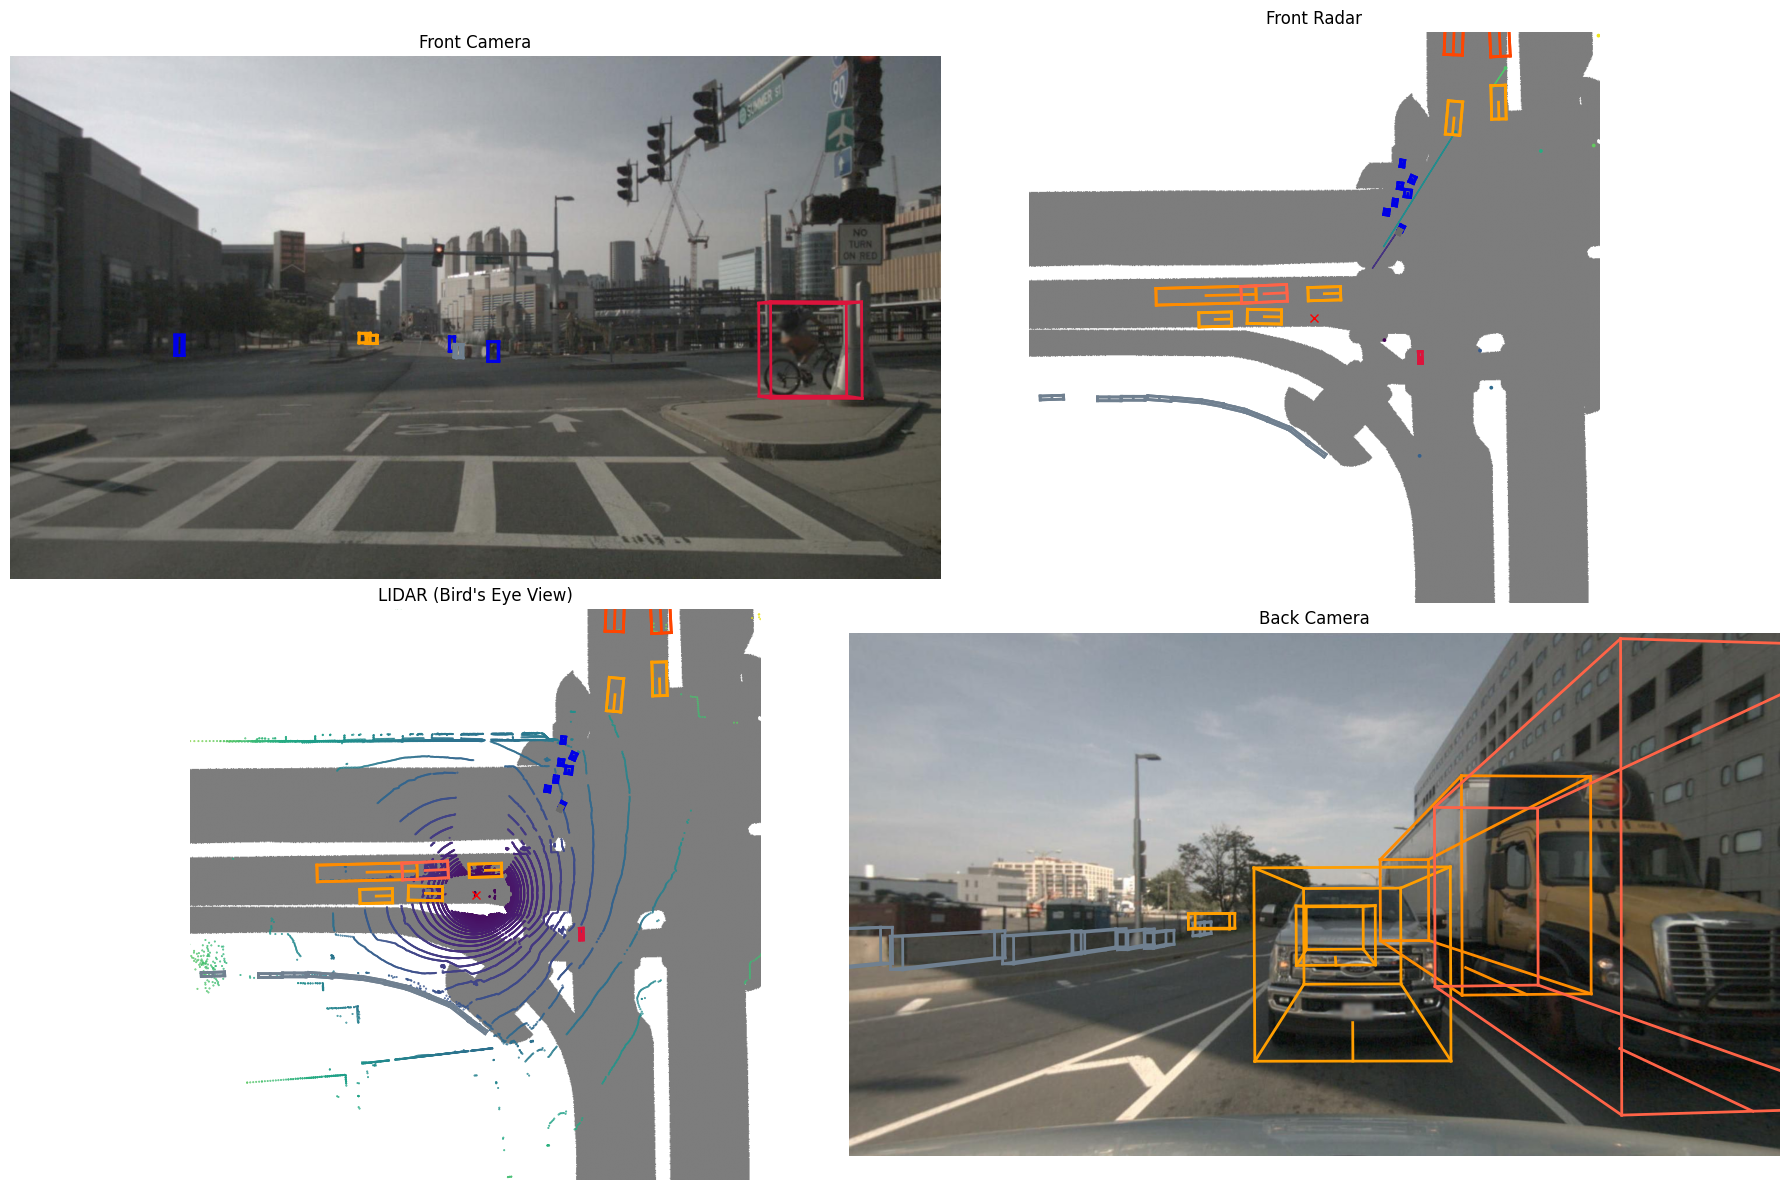

In [2]:
from nuscenes.nuscenes import NuScenes

# 2. Initialize the NuScenes object pointing to Kaggle's read-only input directory
nusc = NuScenes(version='v1.0-mini', dataroot='/kaggle/input/datasets/aadimator/nuscenes-mini', verbose=True)

# 3. Get the very first "Scene" (a 20-second continuous video clip)
my_scene = nusc.scene[2]

# 4. Get the token (ID) for the very first "Sample" (snapshot) in that scene
first_sample_token = my_scene['first_sample_token']

# 5. Fetch the actual sample data using the token
my_sample = nusc.get('sample', first_sample_token)

import matplotlib.pyplot as plt

# 1. Create the figure and a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 2. Render Front Camera (Top-Left)
# Setting verbose=False prevents the SDK from 'finishing' the plot early
nusc.render_sample_data(my_sample['data']['CAM_FRONT'], ax=axes[0, 0], verbose=False)
axes[0, 0].set_title("Front Camera")

# 3. Render Front Radar (Top-Right)
nusc.render_sample_data(my_sample['data']['RADAR_FRONT'], ax=axes[0, 1], verbose=False)
axes[0, 1].set_title("Front Radar")

# 4. Render LIDAR Top-Down (Bottom-Left)
nusc.render_sample_data(my_sample['data']['LIDAR_TOP'], ax=axes[1, 0], verbose=False)
axes[1, 0].set_title("LIDAR (Bird's Eye View)")

# 5. Render Back Camera (Bottom-Right)
nusc.render_sample_data(my_sample['data']['CAM_BACK'], ax=axes[1, 1], verbose=False)
axes[1, 1].set_title("Back Camera")

# 6. Final display call
plt.tight_layout()
plt.show()

In [5]:
%cd /kaggle/working/CenterFusion/src/tools
# Format the training data
!python convert_nuScenes.py --nusc_path data/nuscenes --nusc_version v1.0-mini --split mini_train

# Format the validation data
!python convert_nuScenes.py --nusc_path data/nuscenes --nusc_version v1.0-mini --split mini_val

/kaggle/working/CenterFusion/src/tools
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.542 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
scene_name scene-0103
scene_name scene-0916
reordering images
mini_val 486 images 4910 boxes
out_path ../../data/nuscenes/annotations_6sweeps/mini_val.json
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.508 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
scene_name scene-0061
scene_name scene-0553
scene_name scene-0655
scene_name scene-0757
scene_name scene-0796
scene_name scene-1077
scene_name scene-1094
scene

In [59]:
%cd /kaggle/working/CenterFusion
!ls -lh /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/

/kaggle/working/CenterFusion
total 207M
-rw-r--r-- 1 root root 164M May  8 18:24 mini_train.json
-rw-r--r-- 1 root root  43M May  8 18:20 mini_val.json


In [63]:
# Crucial for report
import json
from collections import Counter

def analyze_coco_json(file_path):
    print(f"Loading {file_path}...")
    with open(file_path, 'r') as f:
        data = json.load(f)
        
    # 1. Get total images
    num_images = len(data.get('images', []))
    print(f"Total Images: {num_images}")
    
    # 2. Map category IDs to readable names
    cat_mapping = {cat['id']: cat['name'] for cat in data.get('categories', [])}
    
    # 3. Count every 3D bounding box by its class
    category_counts = Counter()
    for ann in data.get('annotations', []):
        cat_name = cat_mapping.get(ann['category_id'], 'Unknown')
        category_counts[cat_name] += 1
        
    print(f"Total Annotations (3D Bounding Boxes): {len(data.get('annotations', []))}")
    print("\n--- Breakdown by Class ---")
    
    # Print sorted by highest count
    for cat_name, count in category_counts.most_common():
        print(f"{cat_name}: {count}")
    print("="*40 + "\n")

# Run it on both files
# Note: If your previous 'ls' command showed these files directly in the CenterFusion folder, 
# change the base_path to "/kaggle/working/CenterFusion/"
base_path = "/kaggle/working/CenterFusion/data/nuscenes/annotations/"

try:
    analyze_coco_json(base_path + "mini_train.json")
    analyze_coco_json(base_path + "mini_val.json")
except FileNotFoundError as e:
    print(f"File not found. Check if the path is correct: {e}")

Loading /kaggle/working/CenterFusion/data/nuscenes/annotations/mini_train.json...
Total Images: 1938
Total Annotations (3D Bounding Boxes): 14694

--- Breakdown by Class ---
car: 5607
pedestrian: 3568
barrier: 2389
traffic_cone: 1301
truck: 650
bus: 455
motorcycle: 245
construction_vehicle: 230
bicycle: 186
trailer: 63

Loading /kaggle/working/CenterFusion/data/nuscenes/annotations/mini_val.json...
Total Images: 486
Total Annotations (3D Bounding Boxes): 4910

--- Breakdown by Class ---
car: 2894
pedestrian: 1417
motorcycle: 283
truck: 160
bus: 57
bicycle: 56
traffic_cone: 43



In [37]:
# Quick scan of the options file for augmentation keywords
!grep -E "flip|scale|shift|rotate|aug" /kaggle/working/CenterFusion/src/lib/opts.py

    self.parser.add_argument('--flip_test', action='store_true',
                             help='flip data augmentation.')
    self.parser.add_argument('--test_scales', type=str, default='1',
                             help='multi scale test augmentation.')
    self.parser.add_argument('--depth_scale', type=float, default=1,
                             help='not use the random crop data augmentation'
    self.parser.add_argument('--shift', type=float, default=0,
                                  'apply shift augmentation.')
    self.parser.add_argument('--scale', type=float, default=0,
                                  'apply scale augmentation.')
    self.parser.add_argument('--aug_rot', type=float, default=0, 
                                  'rotation augmentation.')
    self.parser.add_argument('--rotate', type=float, default=0,
                                  'apply rotation augmentation.')
    self.parser.add_argument('--flip', type=float, default=0.5,
                  

Loading Original Dataset...
Fix size testing.
training chunk_sizes: [32]
Dataset version v1.0-mini
==> initializing mini_train data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_train.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=5.15s)
creating index...
index created!
Loaded mini_train 1938 samples
Loading Augmented Dataset...
Fix size testing.
training chunk_sizes: [32]
Dataset version v1.0-mini
==> initializing mini_train data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_train.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=4.93s)
creating index...
index created!
Loaded mini_train 1938 samples


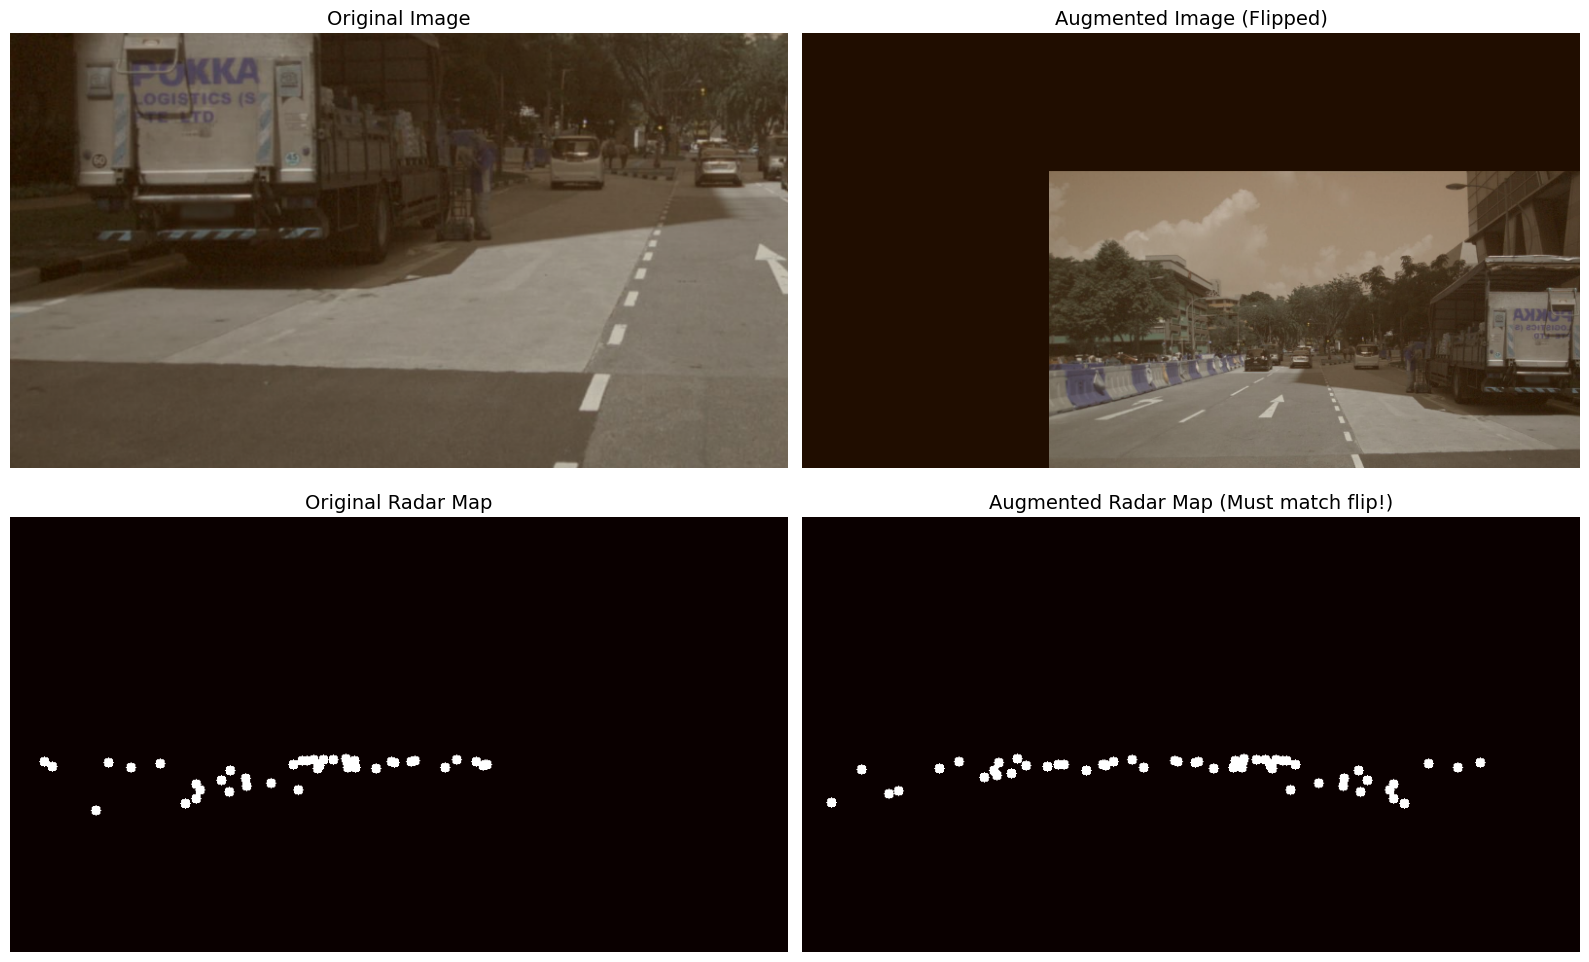

In [99]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# 1. Add the internal library paths
sys.path.append('/kaggle/working/CenterFusion/src/lib')
from opts import opts
from dataset.dataset_factory import dataset_factory

def create_dataset(flip_probability):
    """Helper function to initialize the dataset with specific flip settings"""
    
    # THE FIX: We added '--pointcloud' and '--radar_sweeps', '6' to wake up the radar loader!
    opt = opts().parse([
        'ddd', 
        '--dataset', 'nuscenes', 
        '--pointcloud', 
        '--radar_sweeps', '6'
    ])
    
    # Inject the required variables
    opt.data_dir = '/kaggle/working/CenterFusion/data'
    opt.dataset_version = 'v1.0-mini'
    opt.heads = {'hm': 10, 'reg': 2, 'wh': 2, 'dep': 1, 'rot': 8, 'dim': 3, 'velocity': 3}
    opt.num_classes = 10 
    opt.input_w = 800
    opt.input_h = 448
    opt.down_ratio = 4
    opt.output_w = opt.input_w // opt.down_ratio
    opt.output_h = opt.input_h // opt.down_ratio
    
    # Force augmentation settings
    opt.flip = flip_probability
    opt.scale = 0.0  # Kept at 0 so we can compare the exact pixel mirroring
    opt.shift = 0.0
    
    Dataset = dataset_factory[opt.dataset]
    return Dataset(opt, 'mini_train')

# 2. Initialize two versions of the dataset
print("Loading Original Dataset...")
dataset_original = create_dataset(flip_probability=0.0)

print("Loading Augmented Dataset...")
dataset_augmented = create_dataset(flip_probability=1.0)

# 3. Pull the exact same sample from both
sample_idx = 0
batch_orig = dataset_original[sample_idx]
batch_aug = dataset_augmented[sample_idx]

import cv2

# 4. Helper function to extract, denormalize, and ENHANCE images
def extract_visuals(batch):
    img_tensor = batch['image']
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)
    
    if hasattr(img_tensor, 'cpu'):
        img_tensor = img_tensor.cpu().numpy()
        
    rgb = ((img_tensor[:3, :, :] * std + mean).transpose(1, 2, 0) * 255).clip(0, 255).astype(np.uint8)
    
    # Blank canvas
    radar_visible = np.zeros((img_tensor.shape[1], img_tensor.shape[2]), dtype=np.uint8)
    
    if 'pc_2d' in batch:
        pc_2d = batch['pc_2d']
        if hasattr(pc_2d, 'cpu'): pc_2d = pc_2d.cpu().numpy()
            
        pc_N_raw = batch.get('pc_N', pc_2d.shape[1] if len(pc_2d.shape) > 1 else 0)
        try:
            pc_N = int(np.squeeze(pc_N_raw))
        except Exception:
            pc_N = int(pc_N_raw[0]) 
            
        # THE FIX: pc_2d is in 1600x900. We must scale it to the 800x448 tensor size!
        orig_w, orig_h = 1600.0, 900.0
        target_h, target_w = radar_visible.shape
        scale_x = target_w / orig_w
        scale_y = target_h / orig_h
        
        # CenterFusion's typical shape for pc_2d is [3, N] -> [x, y, depth]
        if pc_2d.shape[0] in [2, 3]:
            xs = pc_2d[0, :pc_N]
            ys = pc_2d[1, :pc_N]
        else:
            xs = pc_2d[:pc_N, 0]
            ys = pc_2d[:pc_N, 1]
            
        import cv2
        points_plotted = 0
        
        # Plot points using the correct downscaling
        for x, y in zip(xs, ys):
            ix, iy = int(x * scale_x), int(y * scale_y)
            if 0 <= ix < target_w and 0 <= iy < target_h:
                # Draw a bright white, visible circle
                cv2.circle(radar_visible, (ix, iy), radius=5, color=(255,), thickness=-1)
                points_plotted += 1
                
        if points_plotted == 0:
            print(f"NOTE: 0 radar points mapped on screen. (pc_N was {pc_N}).")
    else:
        print(f"Warning: No radar keys ('pc_2d') found! Available keys: {list(batch.keys())}")
        
    return rgb, radar_visible

# Re-run your extraction
rgb_orig, radar_orig = extract_visuals(batch_orig)
rgb_aug, radar_aug = extract_visuals(batch_aug)

# 5. Plot the Ultimate Verification Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top Left: Original RGB
axes[0, 0].imshow(rgb_orig)
axes[0, 0].set_title("Original Image", fontsize=14)
axes[0, 0].axis('off')

# Top Right: Flipped RGB
axes[0, 1].imshow(rgb_aug)
axes[0, 1].set_title("Augmented Image (Flipped)", fontsize=14)
axes[0, 1].axis('off')

# Bottom Left: Original Radar
axes[1, 0].imshow(radar_orig, cmap='hot')
axes[1, 0].set_title("Original Radar Map", fontsize=14)
axes[1, 0].axis('off')

# Bottom Right: Flipped Radar
axes[1, 1].imshow(radar_aug, cmap='hot')
axes[1, 1].set_title("Augmented Radar Map (Must match flip!)", fontsize=14)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()